In [10]:
!pip install numpy
!pip install scipy
!pip install statsmodels
!pip install matplotlib
!pip install seaborn

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 2.1 MB/s eta 0:00:18
   - -------------------------------------- 1.0/36.6 MB 1.9 MB/s eta 0:00:20
   - -------------------------------------- 1.6/36.6 MB 2.1 MB/s eta 0:00:17
   -- ------------------------------------- 2.1/36.6 MB 2.1 MB/s eta 0:00:17
   -- ------------------------------------- 2.6/36.6 MB 2.1 MB/s eta 0:00:17
   --- ------------------------------------ 3.1/36.6 MB 2.2 MB/s eta 0:00:16
   --- ------------------------------------ 3.4/36.6 MB 2.2 MB/s eta 0:00:16
   ---- ----------------------------------- 3.9/36.6 MB 2.2 MB/s eta 0:00:15
   ---- ----------------------------------- 4.5/36.6 MB 2.2 MB/s eta 0:00:15
   ----- ---------------------------------- 5.0/36.6 MB 2.2 MB/s eta 0:00:15
   ------ --------------------------------- 5.5/36.6 MB 2.2 MB/s eta 0:00:14
   ------ ---

In [3]:
import numpy as np
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.pyplot as plt
import warnings

In [4]:
warnings.filterwarnings('ignore')

In [5]:
# 1. 순열 엔트로피(Permutation Entropy) 계산 함수
def calculate_permutation_entropy(time_series, order=3, delay=1):
    n = len(time_series)
    if n < order:
        return 0.0
    
    patterns = []
    for i in range(n - delay * (order - 1)):
        window = time_series[i : i + delay * order : delay]
        patterns.append(tuple(np.argsort(window)))
        
    unique_patterns, counts = np.unique(patterns, axis=0, return_counts=True)
    probs = counts / len(patterns)
    
    return -np.sum(probs * np.log(probs))

# 2. 4대 Regime별 Toy 시계열 데이터 생성기 (🎓 시각적 거동 매칭 반영)
def generate_toy_data(length=200, seed=42):
    np.random.seed(seed)
    t = np.arange(length)
    data_dict = {}
    
    # ■ Regime 1: Stationary ID (안정적인 백색 잡음 - 저분산 설정)
    data_dict['Regime 1: Stationary ID'] = np.random.normal(0, 0.2, length)
    
    # ■ Regime 2: Gradual Covariate Shift (완만한 우상향 추세 드리프트)
    data_dict['Regime 2: Gradual Shift'] = np.random.normal(0, 0.4, length) + (0.02 * t)
    
    # ■ Regime 3: Abrupt Covariate Shift (🎓 t=100 기점으로 수학적 평균축 '0 -> +10' 급이동 쇼크)
    shock_signal = np.random.normal(0, 0.4, length)
    shock_signal[length // 2:] = np.random.normal(0, 0.4, length // 2) + 10.0
    data_dict['Regime 3: Abrupt Shock'] = shock_signal
    
    # ■ Regime 4: High-Entropy Stochastic Degradation (🎓 t=100 기점으로 '정밀 사인파 -> 고주파 카오스 잡음' 패턴 붕괴)
    pre_shock_pattern = 0.5 * np.sin(2 * np.pi * t[:length//2] / 25) + np.random.normal(0, 0.05, length//2)
    
    # 로지스틱 맵 변형을 통한 비선형 카오스 데이터 생성 (t=100 이후)
    chaotic = np.zeros(length // 2)
    chaotic[0] = 0.4
    for i in range(1, length // 2):
        chaotic[i] = 3.99 * chaotic[i-1] * (1 - chaotic[i-1])
    post_shock_pattern = (chaotic - 0.5) * 4 + np.random.normal(0, 0.4, length//2)
    
    data_dict['Regime 4: Chaotic Noise'] = np.concatenate([pre_shock_pattern, post_shock_pattern])
    
    return data_dict, t

# 3. 2단계 계층적 게이팅 아키텍처 (Hierarchical Gating Pipeline)
def hierarchical_gating_router(window_data):
    L = len(window_data)
    half = L // 2
    
    # ----------------------------------------------------
    # [1단계: Root Gate] 정상성 이진 판별 (Stationarity Probing)
    # ----------------------------------------------------
    adf_result = adfuller(window_data)
    p_adf = adf_result[1]
    
    kpss_result = kpss(window_data, regression='ct')
    kpss_stat = kpss_result[0]
    kpss_crit_5pct = kpss_result[3]['5%']
    
    # 두 검정이 모두 정상성을 보증할 때만 Regime 1 (Early-Exit)
    if (p_adf < 0.05) and (kpss_stat <= kpss_crit_5pct):
        return "Regime 1: Stationary In-Distribution (Early-Exit 가동)", {}

    # ----------------------------------------------------
    # [2단계: Leaf Gate] 비정상성 세부 분류 (OOD Leaf Router)
    # ----------------------------------------------------
    first_half = window_data[:half]
    second_half = window_data[half:]
    
    # 메타 특징 추출 (f_NS)
    f_MeanDrift = abs(np.mean(second_half) - np.mean(first_half)) / (np.std(window_data) + 1e-8)
    f_VarDrift = np.var(second_half) / (np.var(first_half) + 1e-8)
    if f_VarDrift < 1.0 and f_VarDrift > 0:
        f_VarDrift = 1.0 / f_VarDrift
        
    f_Kurt = stats.kurtosis(window_data, fisher=False)
    f_PermEn = calculate_permutation_entropy(window_data, order=3, delay=1)
    
    features = {
        "Mean Drift Ratio": round(f_MeanDrift, 3),
        "Variance Drift Ratio": round(f_VarDrift, 3),
        "Kurtosis (4th Moment)": round(f_Kurt, 3),
        "Permutation Entropy": round(f_PermEn, 3)
    }
    
    # 🎓 변경된 극적 데이터 구조에 맞추어 매핑 경계 임계값 최적화 조정
    # Regime 4 후반부는 순열 무작위도가 극대화됨 (PermEn > 1.62)
    if f_PermEn > 1.62:
        return "Regime 4: High-Entropy Stochastic Degradation (VBLoRA 매핑)", features
    # Regime 3는 전후반 평균이 폭발적으로 단절됨 (MeanDrift가 극단적으로 솟구침)
    elif f_MeanDrift > 1.5 or f_Kurt > 5.0 or f_VarDrift > 5.0:
        return "Regime 3: Abrupt Covariate Shift (DoRA 매핑)", features
    else:
        return "Regime 2: Gradual Covariate Shift (LoRA / Fourier-LoRA 매핑)", features

# 4. 통합 시각화 및 라우팅 검증 실행 함수
def plot_and_verify_proposed_regimes():
    # 데이터셋 로드
    data_dict, t = generate_toy_data(length=200)
    
    # Matplotlib 서브플롯 설정
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()
    
    colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
    
    print("="*80)
    print(" Ph.D. Thesis Framework: Hierarchical Gating Verification")
    print("="*80)
    
    for idx, (name, series) in enumerate(data_dict.items()):
        ax = axes[idx]
        
        # ➔ 라우터 통과시켜 실시간 판정 정보 및 특징 획득
        predicted_regime, extracted_feats = hierarchical_gating_router(series)
        
        # 터미널 콘솔창 결과 출력
        print(f"\n[🎯 원본 입력 시계열]: {name}")
        print(f" ➔ 라우터 최종 판정: {predicted_regime}")
        if extracted_feats:
            print(f" ➔ 추출된 특징 공간(f_NS): {extracted_feats}")
        else:
            print(" ➔ Strict 정상성 만족으로 인한 2단계 메타 연산 Skip (자원 최적화 완료)")
            
        # ➔ 시각화 그래프 그리기
        ax.plot(t, series, color=colors[idx], linewidth=1.8, label='Input Context')
        
        # 🎓 각 Regime별 최적 가이드라인 세팅
        if idx == 1:   # Regime 2 드리프트 선형 추세 시각화
            ax.plot(t, 0.02 * t, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Mean Trend Line')
        elif idx == 2: # Regime 3 구조적 단절선 및 도약 전후 평균선 가이드 탑재
            ax.axvline(100, color='darkred', linestyle=':', linewidth=2, label='Shock Trigger Point (t=100)')
            ax.hlines(y=0, xmin=0, xmax=100, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
            ax.hlines(y=10, xmin=100, xmax=200, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='Shifted Mean')
        elif idx == 3: # Regime 4 패턴 붕괴 변곡점 시각화
            ax.axvline(100, color='darkgreen', linestyle=':', linewidth=2, label='Pattern Disruption Point')
        else:          # Regime 1 평시 기저 평균선
            ax.axhline(np.mean(series), color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='Window Mean')
            
        # 그래프 데코레이션
        ax.set_title(f"■ {name}", fontsize=13, fontweight='bold', pad=10)
        
        # 그래프 좌측 상단에 라우터가 실제 판단한 결론을 박스로 마킹
        display_text = f"Router Decision:\n{predicted_regime.split('(')[0].strip()}"
        ax.text(0.02, 0.05, display_text, transform=ax.transAxes, fontsize=10,
                color='black', weight='semibold', bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray'))
        
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_ylabel("Value Magnitude", fontsize=10)
        ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
        
        # 🎓 바뀐 밸류 스케일에 따라 깔끔하게 여백 자동 설정
        ax.set_ylim(np.min(series) - 1.5, np.max(series) + 1.5)

    fig.suptitle("Ph.D. Dissertation Context Window: Modified 4-Regime Taxonomy Simulation", 
                 fontsize=16, fontweight='bold', y=0.96)
    
    for ax in [axes[2], axes[3]]:
        ax.set_xlabel("Time Sequence Index (Streaming Context Window)", fontsize=11)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.savefig("time_series_4_regimes.png", dpi=300)
    print("\n" + "="*80)
    print(" ➔ 시각화 차트가 'time_series_4_regimes.png' 파일로 저장되었습니다.")
    print("="*80)
    plt.show()

findfont: Failed to find font weight semibold, now using 700.


 Ph.D. Thesis Framework: Hierarchical Gating Verification

[🎯 원본 입력 시계열]: Regime 1: Stationary ID
 ➔ 라우터 최종 판정: Regime 1: Stationary In-Distribution (Early-Exit 가동)
 ➔ Strict 정상성 만족으로 인한 2단계 메타 연산 Skip (자원 최적화 완료)

[🎯 원본 입력 시계열]: Regime 2: Gradual Shift
 ➔ 라우터 최종 판정: Regime 4: High-Entropy Stochastic Degradation (VBLoRA 매핑)
 ➔ 추출된 특징 공간(f_NS): {'Mean Drift Ratio': np.float64(1.657), 'Variance Drift Ratio': np.float64(1.047), 'Kurtosis (4th Moment)': np.float64(2.07), 'Permutation Entropy': np.float64(1.78)}

[🎯 원본 입력 시계열]: Regime 3: Abrupt Shock
 ➔ 라우터 최종 판정: Regime 4: High-Entropy Stochastic Degradation (VBLoRA 매핑)
 ➔ 추출된 특징 공간(f_NS): {'Mean Drift Ratio': np.float64(1.993), 'Variance Drift Ratio': np.float64(1.007), 'Kurtosis (4th Moment)': np.float64(1.028), 'Permutation Entropy': np.float64(1.751)}

[🎯 원본 입력 시계열]: Regime 4: Chaotic Noise
 ➔ 라우터 최종 판정: Regime 1: Stationary In-Distribution (Early-Exit 가동)
 ➔ Strict 정상성 만족으로 인한 2단계 메타 연산 Skip (자원 최적화 완료)

 ➔ 시각화 차트가 'time_series_4_regi

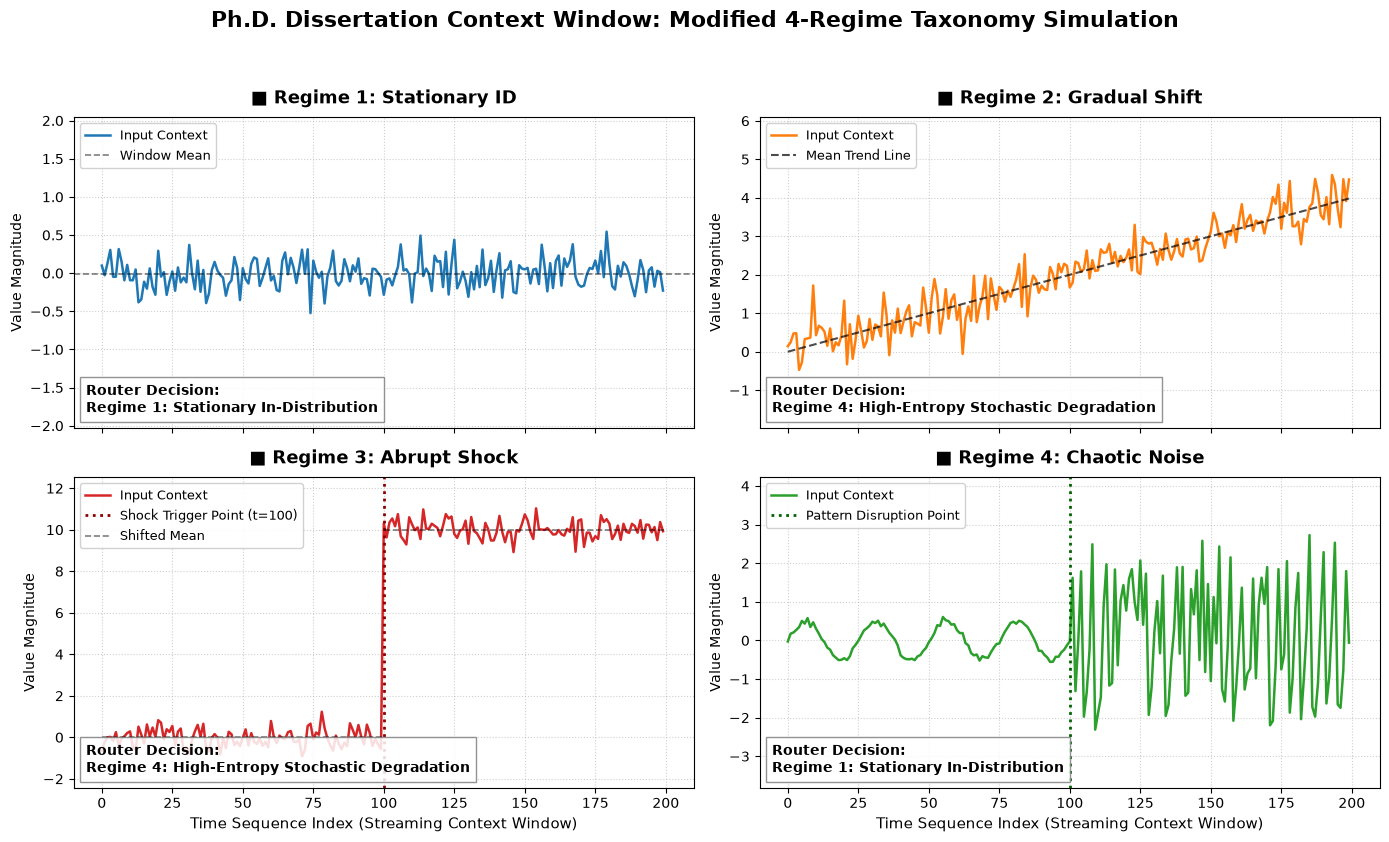

In [6]:
plot_and_verify_proposed_regimes()

ValueError: too many values to unpack (expected 2)